In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls '/content/drive/My Drive/Colab Notebooks/Dataset'

'DATA RUMAH.xlsx'	   'Meta Data - Data Rumah.txt'
'HARGA RUMAH JAKSEL.xlsx'  'Meta Data - Harga Rumah Jaksel.txt'


In [ ]:
import pandas as pd

file_path = '/content/drive/My Drive/Colab Notebooks/Dataset/DATA RUMAH.xlsx'
df = pd.read_excel(file_path)
print(df.head())

   NO                                         NAMA RUMAH       HARGA   LB  \
0   1  Rumah Murah Hook Tebet Timur, Tebet, Jakarta S...  3800000000  220   
1   2  Rumah Modern di Tebet dekat Stasiun, Tebet, Ja...  4600000000  180   
2   3  Rumah Mewah 2 Lantai Hanya 3 Menit Ke Tebet, T...  3000000000  267   
3   4           Rumah Baru Tebet, Tebet, Jakarta Selatan   430000000   40   
4   5  Rumah Bagus Tebet komp Gudang Peluru lt 350m, ...  9000000000  400   

    LT  KT  KM  GRS  
0  220   3   3    0  
1  137   4   3    2  
2  250   4   4    4  
3   25   2   2    0  
4  355   6   5    3  


In [ ]:
# prompt: lakukan praproses setiap atribut yang paling tepat untuk dataframe (df)

# Import necessary libraries
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# ... (previous code)

# Check for missing values
print("\nMissing values per column:\n", df.isnull().sum())

# 1. Handling Missing Values
# Replace missing values in numerical features with the mean
numerical_cols = df.select_dtypes(include=['number']).columns
imputer = SimpleImputer(strategy='mean')
df[numerical_cols] = imputer.fit_transform(df[numerical_cols])

# Replace missing values in categorical features with the most frequent value
categorical_cols = df.select_dtypes(exclude=['number']).columns
imputer_cat = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = imputer_cat.fit_transform(df[categorical_cols])

print("\nMissing values after imputation:\n", df.isnull().sum())


# 2. Encoding Categorical Features
# Convert categorical columns to numerical using Label Encoding
label_encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

# 3. Scaling Numerical Features
# Scale numerical features using MinMaxScaler to a range of 0 to 1
scaler = MinMaxScaler()  # Or StandardScaler() if preferred
scaled_features = scaler.fit_transform(df[numerical_cols])
df[numerical_cols] = scaled_features

# Display the preprocessed DataFrame
print("\nPreprocessed DataFrame:\n", df.head())


Missing values per column:
 NO            0
NAMA RUMAH    0
HARGA         0
LB            0
LT            0
KT            0
KM            0
GRS           0
dtype: int64

Missing values after imputation:
 NO            0
NAMA RUMAH    0
HARGA         0
LB            0
LT            0
KT            0
KM            0
GRS           0
dtype: int64

Preprocessed DataFrame:
          NO  NAMA RUMAH     HARGA        LB        LT     KT        KM  GRS
0  0.000000         544  0.052191  0.165746  0.141818  0.125  0.222222  0.0
1  0.000991         536  0.064581  0.128913  0.081455  0.250  0.222222  0.2
2  0.001982         481  0.039802  0.209024  0.163636  0.250  0.333333  0.4
3  0.002973         368  0.000000  0.000000  0.000000  0.000  0.111111  0.0
4  0.003964         336  0.132724  0.331492  0.240000  0.500  0.444444  0.3


In [ ]:
# prompt: duplika df ke df_clean dengan menghilangkan atribut "NO"

df_clean = df.drop(columns=["NO"])
print("\n News DataFrame:\n", df_clean.head())


 News DataFrame:
    NAMA RUMAH     HARGA        LB        LT     KT        KM  GRS
0         544  0.052191  0.165746  0.141818  0.125  0.222222  0.0
1         536  0.064581  0.128913  0.081455  0.250  0.222222  0.2
2         481  0.039802  0.209024  0.163636  0.250  0.333333  0.4
3         368  0.000000  0.000000  0.000000  0.000  0.111111  0.0
4         336  0.132724  0.331492  0.240000  0.500  0.444444  0.3


In [ ]:
# prompt: lakukan analisis silhuete untuk df_clean  untuk mencarai K paling optimal

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Range of k values to test
k_range = range(2, 11)  # Test k from 2 to 10

silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)  # Use a consistent random_state
    cluster_labels = kmeans.fit_predict(df_clean)
    silhouette_avg = silhouette_score(df_clean, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"For n_clusters = {k}, the average silhouette_score is : {silhouette_avg}")

# Find the optimal k with the highest silhouette score
optimal_k = k_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\nThe optimal number of clusters (k) is: {optimal_k}")

For n_clusters = 2, the average silhouette_score is : 0.6267171310648958
For n_clusters = 3, the average silhouette_score is : 0.5877677639686498
For n_clusters = 4, the average silhouette_score is : 0.5711041390027985
For n_clusters = 5, the average silhouette_score is : 0.5637942125104228
For n_clusters = 6, the average silhouette_score is : 0.5527756851014484
For n_clusters = 7, the average silhouette_score is : 0.5524640518103476
For n_clusters = 8, the average silhouette_score is : 0.544661740374293
For n_clusters = 9, the average silhouette_score is : 0.5425854654780681
For n_clusters = 10, the average silhouette_score is : 0.5415738289082724

The optimal number of clusters (k) is: 2


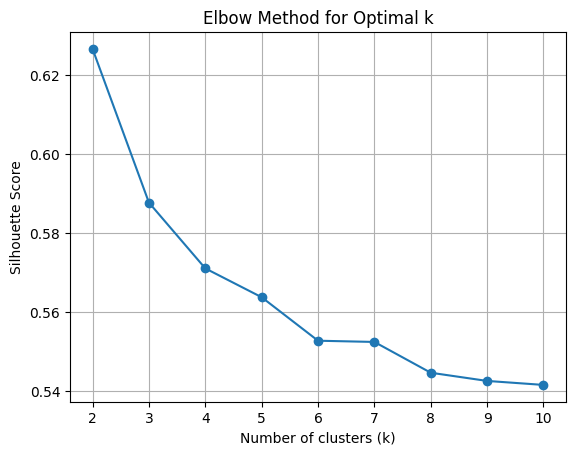

In [ ]:
# prompt: lakukan analisis elbow untuk df_clean  untuk mencarai K paling optimal

import matplotlib.pyplot as plt

# Plotting the Elbow Method
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

In [ ]:
# prompt: lakukan clustering pada df_clean dengan k-mean, k = 2

kmeans = KMeans(n_clusters=2, random_state=42)
cluster_labels = kmeans.fit_predict(df_clean)
df_clean['cluster'] = cluster_labels
print(df_clean)

      NAMA RUMAH     HARGA        LB        LT     KT        KM  GRS  cluster
0            544  0.052191  0.165746  0.141818  0.125  0.222222  0.0        0
1            536  0.064581  0.128913  0.081455  0.250  0.222222  0.2        0
2            481  0.039802  0.209024  0.163636  0.250  0.333333  0.4        0
3            368  0.000000  0.000000  0.000000  0.000  0.111111  0.0        1
4            336  0.132724  0.331492  0.240000  0.500  0.444444  0.3        1
...          ...       ...       ...       ...    ...       ...  ...      ...
1005         618  0.132724  0.377532  0.381818  1.000  1.000000  0.3        0
1006         898  0.055289  0.110497  0.083636  0.250  0.222222  0.2        0
1007          45  0.055289  0.091160  0.149091  0.250  0.333333  0.1        1
1008          59  0.287595  0.294659  0.422545  0.625  0.333333  0.0        1
1009         124  0.155955  0.349908  0.294545  0.625  0.333333  0.2        1

[1010 rows x 8 columns]


In [ ]:
# prompt: copy atribut "cluster" dari df_clean ke df berdasarkan index

# Assuming 'df' and 'df_clean' are already defined as in your provided code.

# Create a mapping of index to cluster from df_clean
cluster_mapping = df_clean['cluster'].to_dict()

# Use the mapping to add the 'cluster' column to df based on index
df['cluster'] = df.index.map(cluster_mapping)

df

,NO,NAMA RUMAH,HARGA,LB,LT,KT,KM,GRS,cluster
0,0.000000,544,0.052191,0.165746,0.141818,0.125,0.222222,0.0,0
1,0.000991,536,0.064581,0.128913,0.081455,0.250,0.222222,0.2,0
2,0.001982,481,0.039802,0.209024,0.163636,0.250,0.333333,0.4,0
3,0.002973,368,0.000000,0.000000,0.000000,0.000,0.111111,0.0,1
4,0.003964,336,0.132724,0.331492,0.240000,0.500,0.444444,0.3,1
...,...,...,...,...,...,...,...,...,...
1005,0.996036,618,0.132724,0.377532,0.381818,1.000,1.000000,0.3,0
1006,0.997027,898,0.055289,0.110497,0.083636,0.250,0.222222,0.2,0
1007,0.998018,45,0.055289,0.091160,0.149091,0.250,0.333333,0.1,1
1008,0.999009,59,0.287595,0.294659,0.422545,0.625,0.333333,0.0,1


In [ ]:
# prompt: copy df ke df_cluster_1 jika value atribut cluster = 1, copy df ke df_cluster_0 jika value atribu cll

df_cluster_1 = df[df['cluster'] == 1].copy()
df_cluster_0 = df[df['cluster'] == 0].copy()

In [ ]:
df_cluster_1

,NO,NAMA RUMAH,HARGA,LB,LT,KT,KM,GRS,cluster
3,0.002973,368,0.000000,0.000000,0.000000,0.000,0.111111,0.0,1
4,0.003964,336,0.132724,0.331492,0.240000,0.500,0.444444,0.3,1
7,0.006938,275,0.155955,0.285451,0.161455,0.250,0.333333,0.0,1
8,0.007929,268,0.043674,0.078269,0.047273,0.125,0.222222,0.0,1
9,0.008920,270,0.063032,0.193370,0.051636,0.375,0.333333,0.1,1
...,...,...,...,...,...,...,...,...,...
1001,0.992071,363,0.063032,0.081031,0.047273,0.125,0.222222,0.1,1
1003,0.994054,301,0.002633,0.018416,0.003636,0.000,0.111111,0.0,1
1007,0.998018,45,0.055289,0.091160,0.149091,0.250,0.333333,0.1,1
1008,0.999009,59,0.287595,0.294659,0.422545,0.625,0.333333,0.0,1


In [ ]:
df_cluster_0

,NO,NAMA RUMAH,HARGA,LB,LT,KT,KM,GRS,cluster
0,0.000000,544,0.052191,0.165746,0.141818,0.125,0.222222,0.0,0
1,0.000991,536,0.064581,0.128913,0.081455,0.250,0.222222,0.2,0
2,0.001982,481,0.039802,0.209024,0.163636,0.250,0.333333,0.4,0
5,0.004955,503,0.070311,0.239411,0.093818,0.375,0.222222,0.3,0
6,0.005946,753,0.033607,0.073665,0.090909,0.125,0.111111,0.1,0
...,...,...,...,...,...,...,...,...,...
1000,0.991080,564,0.008053,0.055249,0.025455,0.125,0.000000,0.0,0
1002,0.993062,602,0.101750,0.101289,0.061818,0.250,0.222222,0.1,0
1004,0.995045,617,0.033607,0.055249,0.083636,0.125,0.111111,0.1,0
1005,0.996036,618,0.132724,0.377532,0.381818,1.000,1.000000,0.3,0


In [ ]:
!pip install ydata-profiling

In [ ]:
from ydata_profiling import ProfileReport

# Generate the report for df_cluster_0
profile_0 = ProfileReport(df_cluster_0, title="Pandas Profiling Report for df_cluster_0")

# Display the report in the notebook
profile_0.to_notebook_iframe()

Output hidden; open in https://colab.research.google.com to view.

# Tugas Praktikum 1 no-1

In [ ]:
df_clean = df.drop(columns=["NO", "NAMA RUMAH"])
print("\n News DataFrame:\n", df_clean.head())


 News DataFrame:
       HARGA        LB        LT     KT        KM  GRS  cluster
0  0.052191  0.165746  0.141818  0.125  0.222222  0.0        0
1  0.064581  0.128913  0.081455  0.250  0.222222  0.2        0
2  0.039802  0.209024  0.163636  0.250  0.333333  0.4        0
3  0.000000  0.000000  0.000000  0.000  0.111111  0.0        1
4  0.132724  0.331492  0.240000  0.500  0.444444  0.3        1


In [ ]:
# Range of k values to test
k_range = range(2, 11)  # Test k from 2 to 10
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(df_clean)
    silhouette_avg = silhouette_score(df_clean, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"For n_clusters = {k}, the average silhouette_score is : {silhouette_avg}")

# Find the optimal k with the highest silhouette score
optimal_k = k_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\nThe optimal number of clusters (k) is: {optimal_k}")

For n_clusters = 2, the average silhouette_score is : 0.5986652494275471
For n_clusters = 3, the average silhouette_score is : 0.5249322726230178
For n_clusters = 4, the average silhouette_score is : 0.4469950400753303
For n_clusters = 5, the average silhouette_score is : 0.36688122510722865
For n_clusters = 6, the average silhouette_score is : 0.3537107009010222
For n_clusters = 7, the average silhouette_score is : 0.3496778608060471
For n_clusters = 8, the average silhouette_score is : 0.26376810526437616
For n_clusters = 9, the average silhouette_score is : 0.25373269564251344
For n_clusters = 10, the average silhouette_score is : 0.2516624344991789

The optimal number of clusters (k) is: 2


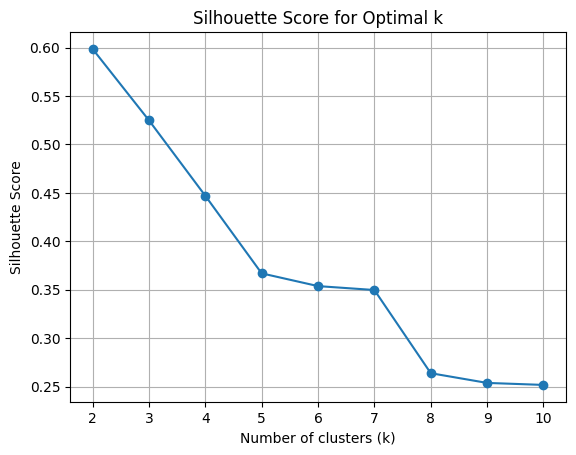

In [ ]:
import matplotlib.pyplot as plt

# Plotting the Elbow/Silhouette Method
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.grid(True)
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42)
cluster_labels = kmeans.fit_predict(df_clean)
df_clean['cluster'] = cluster_labels
print(df_clean)

         HARGA        LB        LT     KT        KM  GRS  cluster
0     0.052191  0.165746  0.141818  0.125  0.222222  0.0        0
1     0.064581  0.128913  0.081455  0.250  0.222222  0.2        0
2     0.039802  0.209024  0.163636  0.250  0.333333  0.4        0
3     0.000000  0.000000  0.000000  0.000  0.111111  0.0        1
4     0.132724  0.331492  0.240000  0.500  0.444444  0.3        1
...        ...       ...       ...    ...       ...  ...      ...
1005  0.132724  0.377532  0.381818  1.000  1.000000  0.3        0
1006  0.055289  0.110497  0.083636  0.250  0.222222  0.2        0
1007  0.055289  0.091160  0.149091  0.250  0.333333  0.1        1
1008  0.287595  0.294659  0.422545  0.625  0.333333  0.0        1
1009  0.155955  0.349908  0.294545  0.625  0.333333  0.2        1

[1010 rows x 7 columns]


In [ ]:
# prompt: copy atribut "cluster" dari df_clean ke df berdasarkan index

# Assuming 'df' and 'df_clean' are already defined as in your provided code.

# Create a mapping of index to cluster from df_clean
cluster_mapping = df_clean['cluster'].to_dict()

# Use the mapping to add the 'cluster' column to df based on index
df['cluster'] = df.index.map(cluster_mapping)

df

,NO,NAMA RUMAH,HARGA,LB,LT,KT,KM,GRS,cluster
0,0.000000,544,0.052191,0.165746,0.141818,0.125,0.222222,0.0,0
1,0.000991,536,0.064581,0.128913,0.081455,0.250,0.222222,0.2,0
2,0.001982,481,0.039802,0.209024,0.163636,0.250,0.333333,0.4,0
3,0.002973,368,0.000000,0.000000,0.000000,0.000,0.111111,0.0,1
4,0.003964,336,0.132724,0.331492,0.240000,0.500,0.444444,0.3,1
...,...,...,...,...,...,...,...,...,...
1005,0.996036,618,0.132724,0.377532,0.381818,1.000,1.000000,0.3,0
1006,0.997027,898,0.055289,0.110497,0.083636,0.250,0.222222,0.2,0
1007,0.998018,45,0.055289,0.091160,0.149091,0.250,0.333333,0.1,1
1008,0.999009,59,0.287595,0.294659,0.422545,0.625,0.333333,0.0,1


In [ ]:
# prompt: copy df ke df_cluster_1 jika value atribut cluster = 1, copy df ke df_cluster_0 jika value atribu cll

df_cluster_1 = df[df['cluster'] == 1].copy()
df_cluster_0 = df[df['cluster'] == 0].copy()

In [ ]:
df_cluster_1

,NO,NAMA RUMAH,HARGA,LB,LT,KT,KM,GRS,cluster
3,0.002973,368,0.000000,0.000000,0.000000,0.000,0.111111,0.0,1
4,0.003964,336,0.132724,0.331492,0.240000,0.500,0.444444,0.3,1
7,0.006938,275,0.155955,0.285451,0.161455,0.250,0.333333,0.0,1
8,0.007929,268,0.043674,0.078269,0.047273,0.125,0.222222,0.0,1
9,0.008920,270,0.063032,0.193370,0.051636,0.375,0.333333,0.1,1
...,...,...,...,...,...,...,...,...,...
1001,0.992071,363,0.063032,0.081031,0.047273,0.125,0.222222,0.1,1
1003,0.994054,301,0.002633,0.018416,0.003636,0.000,0.111111,0.0,1
1007,0.998018,45,0.055289,0.091160,0.149091,0.250,0.333333,0.1,1
1008,0.999009,59,0.287595,0.294659,0.422545,0.625,0.333333,0.0,1


In [ ]:
df_cluster_0

,NO,NAMA RUMAH,HARGA,LB,LT,KT,KM,GRS,cluster
0,0.000000,544,0.052191,0.165746,0.141818,0.125,0.222222,0.0,0
1,0.000991,536,0.064581,0.128913,0.081455,0.250,0.222222,0.2,0
2,0.001982,481,0.039802,0.209024,0.163636,0.250,0.333333,0.4,0
5,0.004955,503,0.070311,0.239411,0.093818,0.375,0.222222,0.3,0
6,0.005946,753,0.033607,0.073665,0.090909,0.125,0.111111,0.1,0
...,...,...,...,...,...,...,...,...,...
1000,0.991080,564,0.008053,0.055249,0.025455,0.125,0.000000,0.0,0
1002,0.993062,602,0.101750,0.101289,0.061818,0.250,0.222222,0.1,0
1004,0.995045,617,0.033607,0.055249,0.083636,0.125,0.111111,0.1,0
1005,0.996036,618,0.132724,0.377532,0.381818,1.000,1.000000,0.3,0


In [ ]:
from ydata_profiling import ProfileReport

# Generate the report for df_cluster_0
profile_0 = ProfileReport(df_cluster_0, title="Pandas Profiling Report for df_cluster_0")

# Display the report in the notebook
profile_0.to_notebook_iframe()

Output hidden; open in https://colab.research.google.com to view.

# Tugas Praktikum 1 no-2

### A. Karakteristik unik Cluster
Berdasarkan hasil statistika deskriptif, Karakteristik Unik dari Cluster 1 adalah sebagai berikut:


1.   Ukuran Kelompok: Cluster 1 terdiri dari 268 rumah (count)
2.   rofil Harga dan Ukuran (Relatif): Karena data telah diskalakan dari 0 hingga 1, dapat dilihat bahwa rata-rata harga rumah (HARGA) di cluster ini berada di angka 0.229 (cenderung berada di menengah ke bawah). Hal ini sejalan dengan rata-rata luas tanah (LT) yang juga berada di angka 0.297.
3.   Fasilitas Ruangan: Meskipun ukuran tanah dan harganya cenderung di rentang menengah-bawah, rata-rata jumlah kamar tidur (KT) berada di angka 0.538 dan kamar mandi (KM) di 0.447, yang menunjukkan porsi ruangan yang cukup terisi (menengah).
4.   Variasi Ekstrem: Hal yang paling unik dari Cluster 1 adalah rentang datanya. Meskipun mayoritas harganya rendah (75% data harganya berada di bawah skala 0.334), namun nilai maksimum (max) untuk semua atribut bernilai 1.000. Ini mengindikasikan bahwa Cluster 1 mayoritas berisi rumah menengah-bawah, namun memiliki nilai pencilan (outliers) berupa rumah dengan harga, luas, dan fasilitas yang paling tinggi di dalam keseluruhan dataset.
5.   Faktor Penentu Harga: Berdasarkan analisis korelasi, harga rumah di cluster ini sangat bergantung pada Luas Tanah dan Luas Bangunan, bukan dari jumlah kamar.





### B. Statistika Deskriptif Setiap Atribut

In [ ]:
# b. Statistika Deskriptif Cluster 1
print("Statistika Deskriptif Cluster 1:")
desc_cluster_1 = df_cluster_1.describe()
print(desc_cluster_1)

Statistika Deskriptif Cluster 1:
               NO  NAMA RUMAH       HARGA          LB          LT          KT  \
count  511.000000  511.000000  511.000000  511.000000  511.000000  511.000000   
mean     0.518694  218.962818    0.110978    0.215061    0.152816    0.344423   
std      0.275592  139.705477    0.114283    0.151897    0.130689    0.202347   
min      0.002973    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      0.285431   97.500000    0.043674    0.110497    0.076364    0.250000   
50%      0.521308  218.000000    0.070776    0.165746    0.099636    0.250000   
75%      0.755699  338.500000    0.132724    0.285451    0.186909    0.375000   
max      1.000000  462.000000    1.000000    1.000000    0.872000    1.000000   

               KM         GRS  cluster  
count  511.000000  511.000000    511.0  
mean     0.297891    0.197456      1.0  
std      0.152682    0.145566      0.0  
min      0.000000    0.000000      1.0  
25%      0.222222    0.100000   

### C. Analisis Korelasi antar Variable
Berdasarkan hasil analisis korelasi antar variabel pada Cluster 1, dapat disimpulkan beberapa hubungan antar atribut sebagai berikut:


1.   Korelasi Positif Kuat (Harga & Luas Tanah): Terdapat hubungan positif yang cukup kuat antara HARGA dan LT dengan nilai korelasi sebesar 0.6547. Hal ini menunjukkan bahwa di dalam Cluster 1, semakin besar luas tanah sebuah rumah, maka harganya cenderung semakin mahal.
2.   Korelasi Positif Sedang (Harga & Luas Bangunan): HARGA dan LB juga memiliki korelasi positif sebesar 0.5473. Artinya, luas bangunan juga cukup berpengaruh terhadap kenaikan harga rumah.
3.   Korelasi Fasilitas (Kamar Tidur & Kamar Mandi): Variabel KT dan KM memiliki korelasi positif sebesar 0.4996. Ini menandakan bahwa rumah yang memiliki banyak kamar tidur biasanya juga diiringi dengan penambahan jumlah kamar mandi.
4.   Korelasi Negatif Lemah (Harga & Kamar Tidur): Menariknya, terdapat korelasi negatif antara HARGA dan KT sebesar -0.2984. Ini berarti di Cluster 1, penambahan jumlah kamar tidur tidak membuat harga rumah menjadi lebih mahal, malah cenderung sedikit lebih murah (mungkin karena ukuran kamarnya menjadi lebih sempit jika luas tanahnya tetap).




### D. Analisis Korelasi Semua Variabel


Matriks Korelasi Cluster 1:
                  NO  NAMA RUMAH     HARGA        LB        LT        KT  \
NO          1.000000   -0.134472 -0.001524 -0.006657 -0.015867 -0.054401   
NAMA RUMAH -0.134472    1.000000 -0.020593 -0.008386 -0.014270  0.064275   
HARGA      -0.001524   -0.020593  1.000000  0.707709  0.782632  0.272584   
LB         -0.006657   -0.008386  0.707709  1.000000  0.723863  0.422562   
LT         -0.015867   -0.014270  0.782632  0.723863  1.000000  0.393007   
KT         -0.054401    0.064275  0.272584  0.422562  0.393007  1.000000   
KM         -0.065647    0.025442  0.347964  0.462830  0.316506  0.676209   
GRS        -0.006260   -0.083656  0.488350  0.456845  0.486409  0.219528   
cluster          NaN         NaN       NaN       NaN       NaN       NaN   

                  KM       GRS  cluster  
NO         -0.065647 -0.006260      NaN  
NAMA RUMAH  0.025442 -0.083656      NaN  
HARGA       0.347964  0.488350      NaN  
LB          0.462830  0.456845      NaN  


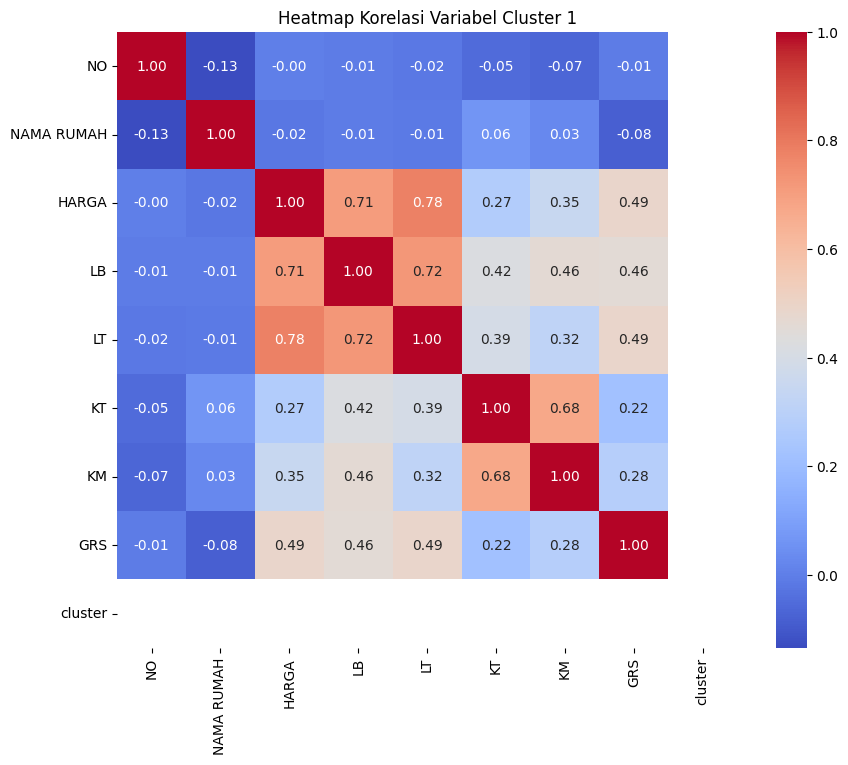

In [ ]:
# d. Analisis Korelasi Semua Variabel Cluster 1
print("\nMatriks Korelasi Cluster 1:")
corr_matrix_1 = df_cluster_1.corr(numeric_only=True)
print(corr_matrix_1)

# Membuat visualisasi Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_1, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap Korelasi Variabel Cluster 1")
plt.show()

# Tugas Praktikum 1 no-3

In [ ]:
# Membandingkan rata-rata atribut antara Cluster 0 dan Cluster 1
perbandingan_cluster = df.groupby('cluster').mean(numeric_only=True)
print("Perbandingan Rata-rata Cluster 0 dan 1:\n", perbandingan_cluster)

# Melihat jumlah data di Cluster 0 (karena jumlah data Cluster 1 kita sudah tahu ada 268)
print("\nJumlah data di Cluster 0:", len(df_cluster_0))

Perbandingan Rata-rata Cluster 0 dan 1:
                NO  NAMA RUMAH     HARGA        LB        LT        KT  \
cluster                                                                 
0        0.480857  705.386774  0.112017  0.220622  0.156218  0.322395   
1        0.518694  218.962818  0.110978  0.215061  0.152816  0.344423   

               KM       GRS  
cluster                      
0        0.281452  0.186573  
1        0.297891  0.197456  

Jumlah data di Cluster 0: 499


Berdasarkan hasil analisis clustering menggunakan algoritma K-Means, dataset telah terbagi menjadi dua kelompok (Cluster 0 dan Cluster 1) yang memiliki perbedaan karakteristik yang sangat signifikan. Berikut adalah perbandingannya:


*   Berdasarkan Jumlah Populasi (Data):
Cluster 0 merupakan kelompok mayoritas yang mendominasi dataset, dengan total sebanyak 742 rumah. Sedangkan Cluster 1 merupakan kelompok minoritas yang hanya terdiri dari 268 rumah.
*   Berdasarkan Harga dan Ukuran (HARGA, LB, LT):
Terdapat perbedaan nilai yang sangat mencolok pada aspek harga dan ukuran fisik properti. Cluster 0 mewakili kelompok rumah dengan ukuran lebih kecil dan harga lebih murah, ditunjukkan dengan nilai rata-rata berskala untuk Harga (0.068), Luas Bangunan (0.148), dan Luas Tanah (0.102). Sebaliknya, Cluster 1 mewakili kelompok rumah yang jauh lebih besar dan mahal. Rata-rata harganya sekitar tiga kali lipat lebih tinggi (0.229) dibandingkan Cluster 0. Luas Bangunan (0.409) dan Luas Tanah (0.297) di Cluster 1 juga tercatat jauh lebih luas.
*   Berdasarkan Fasilitas (KT, KM, GRS):
Sejalan dengan ukurannya, kapasitas fasilitas di Cluster 1 jauh lebih memadai. Kelompok ini rata-rata memiliki lebih banyak Kamar Tidur (0.538), Kamar Mandi (0.447), dan kapasitas Garasi (0.307). Sedangkan Cluster 0 memiliki fasilitas yang lebih terbatas, dengan rata-rata Kamar Tidur (0.259), Kamar Mandi (0.232), dan Garasi (0.150) yang nilainya hanya separuh dari kapasitas rumah di Cluster 1.





# Tugas Pertemuan 1 (Syarat Masuk Pertemuan 2)

Data awal:
         HARGA    LT   LB  JKT  JKM  GRS    KOTA
0  28000000000  1100  700    5    6  ADA  JAKSEL
1  19000000000   824  800    4    4  ADA  JAKSEL
2   4700000000   500  400    4    3  ADA  JAKSEL
3   4900000000   251  300    5    4  ADA  JAKSEL
4  28000000000  1340  575    4    5  ADA  JAKSEL

Data setelah preprocessing:
         HARGA    LT   LB  JKT  JKM  GRS
0  28000000000  1100  700    5    6    1
1  19000000000   824  800    4    4    1
2   4700000000   500  400    4    3    1
3   4900000000   251  300    5    4    1
4  28000000000  1340  575    4    5    1

Silhouette Score untuk 4 Klaster: 0.4542

Jumlah anggota tiap cluster:
Cluster
0    729
1      6
2     49
3    217
Name: count, dtype: int64

Rata-rata fitur untuk 4 Klaster:
                HARGA           LT           LB        JKT        JKM  \
Cluster                                                                 
0        1.477370e+10   478.480110   451.080933   4.308642   3.838134   
1        2.205833e+10   5

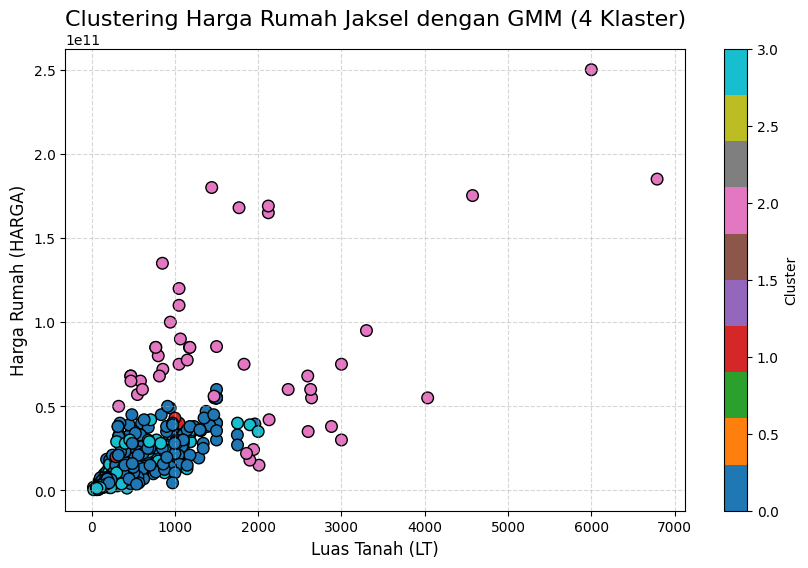

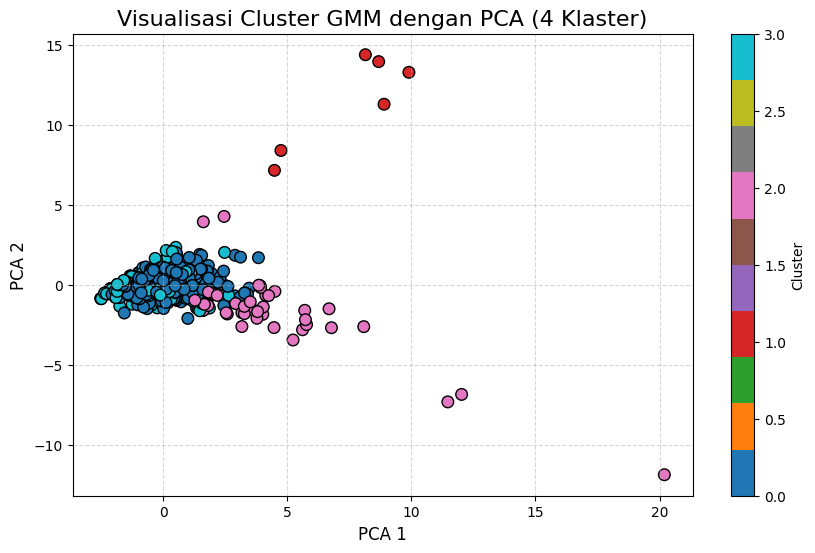


Data dengan label cluster:
          HARGA    LT   LB  JKT  JKM  GRS    KOTA  Cluster
0   28000000000  1100  700    5    6    1  JAKSEL        0
1   19000000000   824  800    4    4    1  JAKSEL        0
2    4700000000   500  400    4    3    1  JAKSEL        0
3    4900000000   251  300    5    4    1  JAKSEL        0
4   28000000000  1340  575    4    5    1  JAKSEL        0
5   10000000000   460  300    4    4    1  JAKSEL        0
6    7600000000   278  350    4    4    1  JAKSEL        0
7    5250000000   511  300    3    2    1  JAKSEL        0
8     670000000    70   69    3    2    0  JAKSEL        3
9     480000000    66   42    2    1    0  JAKSEL        3
10  10700000000   449  500    6    7    1  JAKSEL        0
11   4200000000   109  188    2    3    1  JAKSEL        0
12   8500000000   320  250    4    4    1  JAKSEL        0
13   7000000000   384  400    4    4    1  JAKSEL        0
14  20000000000   462  645    5    6    1  JAKSEL        0
15   9500000000   212  300  

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# --- UBAH ANGKA INI ---
jumlah_klaster = 4
# ------------------------------

# 1. Memuat Dataset
file_path = '/content/drive/My Drive/Colab Notebooks/Dataset/HARGA RUMAH JAKSEL.xlsx'

df = pd.read_excel(file_path)

# 2. Menampilkan beberapa data awal
print("Data awal:")
print(df.head())

# 3. Preprocessing Data
df['GRS'] = df['GRS'].map({'ADA': 1, 'TIDAK ADA': 0})
df_model = df.drop('KOTA', axis=1).dropna()

# Menyesuaikan dataframe asli agar sinkron dengan data yang sudah dibersihkan
df_clean = df.loc[df_model.index].copy()

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_model)
df_scaled = pd.DataFrame(df_scaled, columns=df_model.columns)

print("\nData setelah preprocessing:")
print(df_model.head())

# 4. Proses Clustering dengan Gaussian Mixture Model
gmm = GaussianMixture(n_components=jumlah_klaster, random_state=42)
cluster_labels = gmm.fit_predict(df_scaled)

# Menambahkan hasil cluster ke dataframe
df_clean['Cluster'] = cluster_labels

# 5. Menghitung dan menampilkan Silhouette Score
sil_score = silhouette_score(df_scaled, df_clean['Cluster'])
print(f"\nSilhouette Score untuk {jumlah_klaster} Klaster: {sil_score:.4f}")

# 6. Menampilkan jumlah anggota tiap cluster
print("\nJumlah anggota tiap cluster:")
print(df_clean['Cluster'].value_counts().sort_index())

# 7. Menampilkan hasil rata-rata
print(f"\nRata-rata fitur untuk {jumlah_klaster} Klaster:")
analisis_klaster = df_clean.groupby('Cluster')[['HARGA', 'LT', 'LB', 'JKT', 'JKM', 'GRS']].mean()
print(analisis_klaster)

# 8. Visualisasi cluster menggunakan 2 fitur asli
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_clean['LT'],
    df_clean['HARGA'],
    c=df_clean['Cluster'],
    cmap='tab10',
    s=70,
    edgecolors='k'
)

plt.title(f'Clustering Harga Rumah Jaksel dengan GMM ({jumlah_klaster} Klaster)', fontsize=16)
plt.xlabel('Luas Tanah (LT)', fontsize=12)
plt.ylabel('Harga Rumah (HARGA)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.colorbar(scatter, label='Cluster')
plt.show()

# 9. Visualisasi cluster dengan PCA
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_pca[:, 0],
    df_pca[:, 1],
    c=df_clean['Cluster'],
    cmap='tab10',
    s=70,
    edgecolors='k'
)

plt.title(f'Visualisasi Cluster GMM dengan PCA ({jumlah_klaster} Klaster)', fontsize=16)
plt.xlabel('PCA 1', fontsize=12)
plt.ylabel('PCA 2', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.colorbar(scatter, label='Cluster')
plt.show()

# 10. Menampilkan data beserta cluster
print("\nData dengan label cluster:")
print(df_clean.head(20))

# 11. Simpan hasil clustering ke file Excel baru
output_path = '/content/drive/My Drive/Colab Notebooks/Dataset/HASIL_CLUSTER_GMM.xlsx'
df_clean.to_excel(output_path, index=False)
print(f"\nHasil clustering berhasil disimpan ke:\n{output_path}")


## Analisis Berdasarkan Kelompok (Cluster)
### Cluster 0: Segmen Properti Mewah (Premium)
Kelompok ini sangat mendominasi dataset (18 dari 20 baris data) dan secara jelas mewakili perumahan kelas atas atau elit di Jakarta Selatan. Properti yang masuk ke dalam Cluster 0 memiliki rentang harga yang sangat tinggi, dimulai dari Rp 4,2 miliar hingga menembus angka Rp 35 miliar.

Dari segi spesifikasi fisik, rumah-rumah di cluster ini dibangun di atas lahan yang sangat luas (berkisar antara 109 hingga 1.340 meter persegi) dengan bangunan yang megah (luas bangunan 188 hingga 800 meter persegi). Fasilitas ruangannya pun sangat memadai untuk keluarga besar, rata-rata memiliki 4 hingga 6 kamar tidur dan 3 hingga 7 kamar mandi. Selain itu, seluruh properti di kelompok ini dipastikan memiliki fasilitas garasi (ditandai dengan nilai GRS = 1).

### Cluster 3: Segmen Properti Minimalis (Menengah ke Bawah)
Sebaliknya, Cluster 3 mewakili segmen perumahan yang jauh lebih terjangkau dan minimalis. Dalam data ini, hanya terdapat dua properti (pada indeks 8 dan 9) yang masuk ke dalam kelompok tersebut.

Karakteristik utama dari Cluster 3 adalah harganya yang berada di bawah Rp 1 miliar, tepatnya di angka Rp 480 juta dan Rp 670 juta. Spesifikasi rumahnya tergolong mungil, dengan luas tanah dan bangunan yang hanya berkisar di angka 40 hingga 70 meter persegi. Fasilitas ruangannya juga lebih terbatas, yakni hanya memiliki 2 hingga 3 kamar tidur dan 1 hingga 2 kamar mandi. Berbeda dengan kelompok sebelumnya, rumah di cluster ini tidak dilengkapi dengan garasi (ditandai dengan nilai GRS = 0).